# (Original):

In [74]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("transformed_ainoor.csv")

df= df.dropna()

# One-hot encode categorical variables 'DISTRICT' and 'Item'
df_encoded = pd.get_dummies(df, columns=['DISTRICT', 'Item'], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('h/ha_yield', axis=1)
y = df_encoded['h/ha_yield']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate a model and print MSE and R2
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}: MSE = {mse:.4f}, R² = {r2:.4f}")
    return r2

# List of regression models to evaluate
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge()),
    ("Lasso Regression", Lasso()),
    ("Decision Tree Regression", DecisionTreeRegressor(random_state=42)),
    ("Random Forest Regression", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=42)),
    ("Support Vector Regression", SVR())
]

# Evaluate all models and track the best one
best_r2 = -float('inf')
best_model_name = ""

print("Model Performance Evaluation:\n")
for name, model in models:
    r2 = evaluate_model(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name

print(f"\nBest Model: {best_model_name} with R² = {best_r2:.4f}")


Model Performance Evaluation:

Linear Regression: MSE = 407233.1804, R² = 0.5263
Ridge Regression: MSE = 407235.9150, R² = 0.5263
Lasso Regression: MSE = 408614.6470, R² = 0.5247
Decision Tree Regression: MSE = 564434.6391, R² = 0.3434
Random Forest Regression: MSE = 312444.2995, R² = 0.6365
Gradient Boosting Regression: MSE = 311480.9917, R² = 0.6376
Support Vector Regression: MSE = 827674.1395, R² = 0.0372

Best Model: Gradient Boosting Regression with R² = 0.6376


In [75]:
print(df.isnull().sum())

DISTRICT      0
YEAR          0
PRECTOT       0
T2M           0
T2M_MAX       0
T2M_MIN       0
RH2M          0
Item          0
h/ha_yield    0
dtype: int64


In [76]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 11373 entries, 0 to 11399
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DISTRICT    11373 non-null  object 
 1   YEAR        11373 non-null  int64  
 2   PRECTOT     11373 non-null  float64
 3   T2M         11373 non-null  float64
 4   T2M_MAX     11373 non-null  float64
 5   T2M_MIN     11373 non-null  float64
 6   RH2M        11373 non-null  float64
 7   Item        11373 non-null  object 
 8   h/ha_yield  11373 non-null  float64
dtypes: float64(6), int64(1), object(2)
memory usage: 888.5+ KB


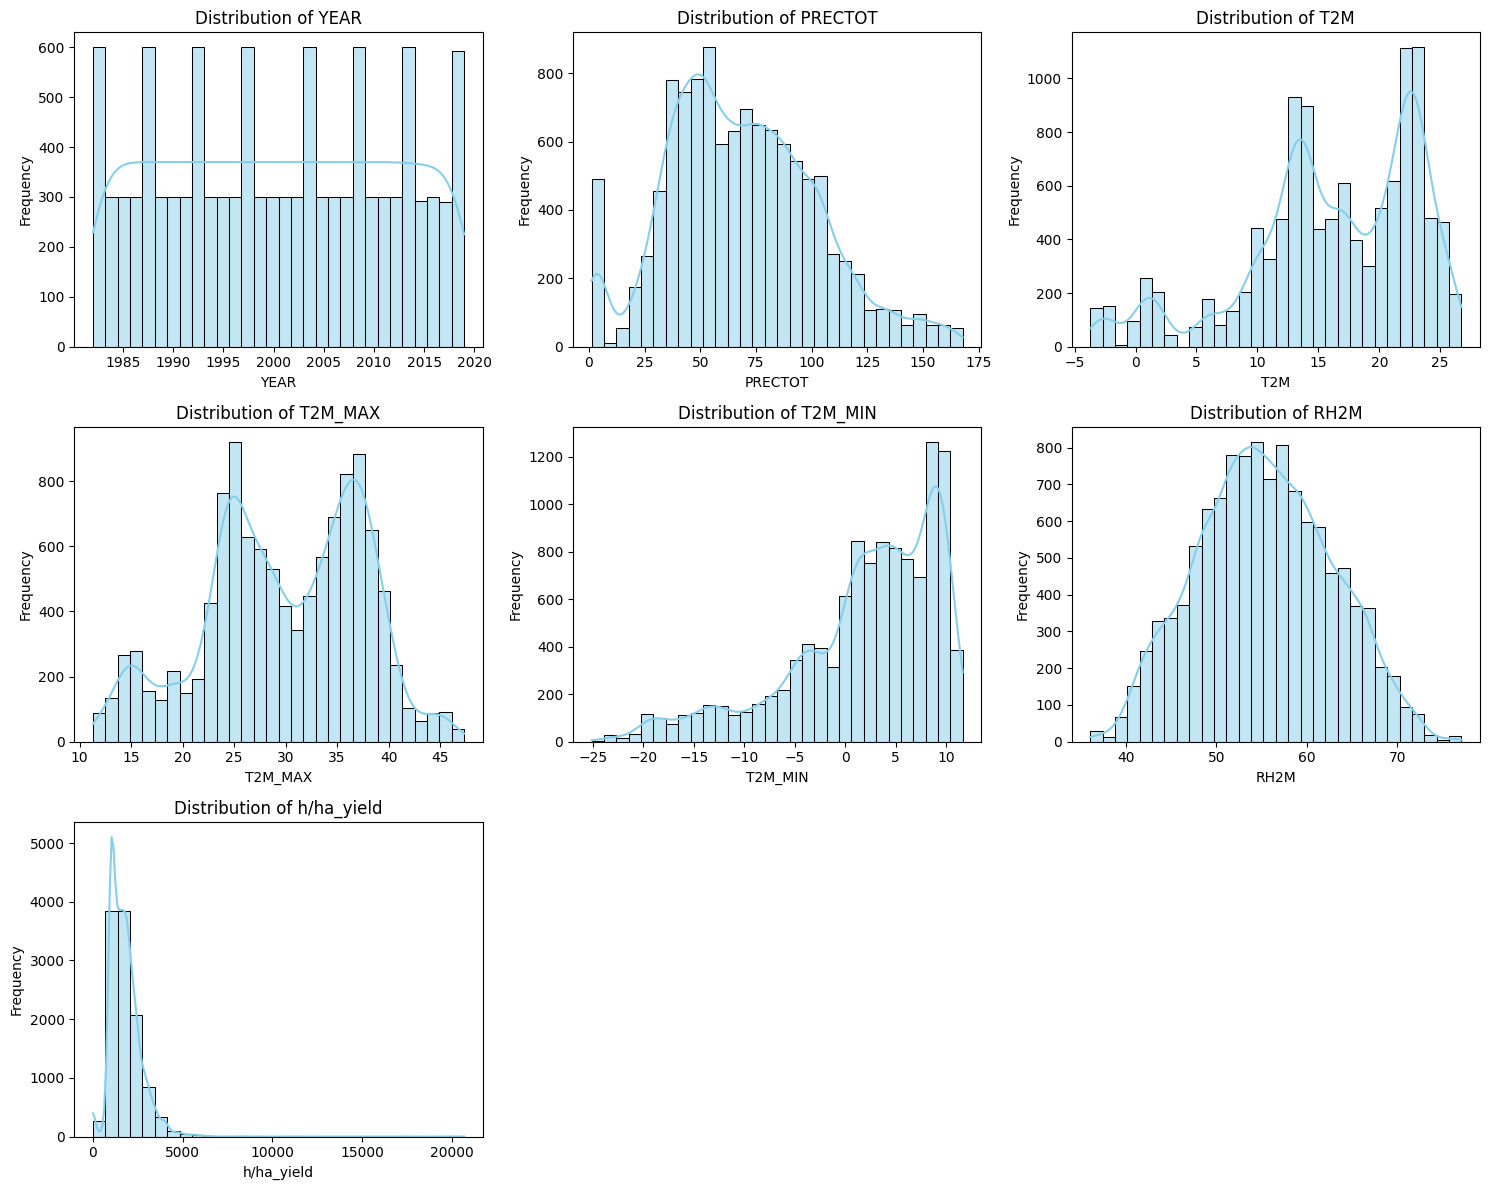

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Identify numeric columns
numeric_cols = df.select_dtypes(include='number').columns

# Set up the plot grid
num_cols = len(numeric_cols)
ncols = 3
nrows = (num_cols + ncols - 1) // ncols

plt.figure(figsize=(15, 4 * nrows))

# Plot each histogram
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(nrows, ncols, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


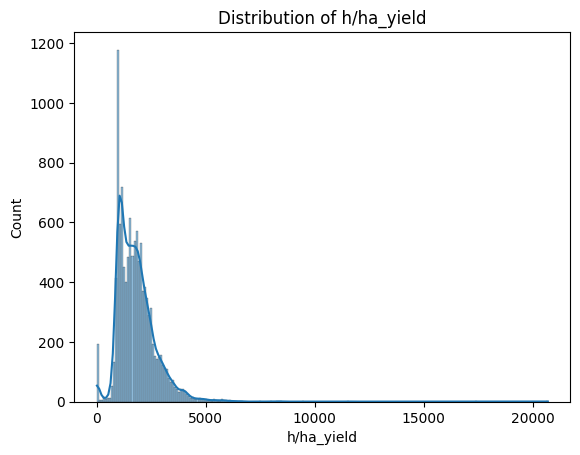

In [78]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['h/ha_yield'], kde=True)
plt.title("Distribution of h/ha_yield")
plt.show()

Data scewed..so better try log transformation on h/ha_feild

In [79]:
import xgboost as xgb

# Prepare data
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)  # Use y_train_log if transformed
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8
}

# Train with early stopping
xgb_model = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dtest, 'test')],
                      early_stopping_rounds=50, verbose_eval=False)

y_pred = xgb_model.predict(dtest)
if 'y_train_log' in locals():
    y_pred = np.expm1(y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"XGBoost: MSE = {mse:.4f}, R² = {r2:.4f}")

XGBoost: MSE = 289702.4184, R² = 0.6630


# (Log Transformed Target) Evaluates both log-scale and original-scale):

In [80]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("transformed_ainoor.csv")

# Drop missing values
df = df.dropna()

# One-hot encode categorical variables 'DISTRICT' and 'Item'
df_encoded = pd.get_dummies(df, columns=['DISTRICT', 'Item'], drop_first=True)

# Define features (X) and apply log1p transformation to the target (y)
X = df_encoded.drop('h/ha_yield', axis=1)
y = np.log1p(df_encoded['h/ha_yield'])  # log(1 + x)

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate a model and print MSE and R2 in both log scale and original scale
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred_log = model.predict(X_test)

    # Evaluate in log scale
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)

    # Convert predictions back to original scale
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)

    # Evaluate in original scale
    mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
    r2_orig = r2_score(y_test_orig, y_pred_orig)

    print(f"{model_name}:")
    print(f"  Log-Scale:     MSE = {mse_log:.4f}, R² = {r2_log:.4f}")
    print(f"  Original-Scale: MSE = {mse_orig:.4f}, R² = {r2_orig:.4f}\n")

    return r2_orig

# List of regression models to evaluate
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge()),
    ("Decision Tree Regression", DecisionTreeRegressor(random_state=42)),
    ("Random Forest Regression", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=42)),
    ("Support Vector Regression", SVR())
]

# Evaluate all models and track the best one
best_r2_orig = -float('inf')
best_r2_log = -float('inf')
best_model_name = ""

print("Model Performance Evaluation:\n")
for name, model in models:
    model.fit(X_train_scaled, y_train)
    y_pred_log = model.predict(X_test_scaled)

    # Log-scale metrics
    mse_log = mean_squared_error(y_test, y_pred_log)
    r2_log = r2_score(y_test, y_pred_log)

    # Convert back to original scale
    y_test_orig = np.expm1(y_test)
    y_pred_orig = np.expm1(y_pred_log)

    # Original-scale metrics
    mse_orig = mean_squared_error(y_test_orig, y_pred_orig)
    r2_orig = r2_score(y_test_orig, y_pred_orig)

    print(f"{name}:")
    print(f"  Log-Scale:      MSE = {mse_log:.4f}, R² = {r2_log:.4f}")
    print(f"  Original-Scale: MSE = {mse_orig:.4f}, R² = {r2_orig:.4f}\n")

    # Track the best model based on original R²
    if r2_orig > best_r2_orig:
        best_r2_orig = r2_orig
        best_r2_log = r2_log
        best_model_name = name

print(f"Best Model: {best_model_name}")
print(f"  R² (Original Scale): {best_r2_orig:.4f}")
print(f"  R² (afte Log tansformation on target):      {best_r2_log:.4f}")


Model Performance Evaluation:

Linear Regression:
  Log-Scale:      MSE = 0.6781, R² = 0.3907
  Original-Scale: MSE = 475644.5834, R² = 0.4467

Ridge Regression:
  Log-Scale:      MSE = 0.6782, R² = 0.3906
  Original-Scale: MSE = 475560.7225, R² = 0.4468

Decision Tree Regression:
  Log-Scale:      MSE = 0.4135, R² = 0.6285
  Original-Scale: MSE = 518860.8985, R² = 0.3964

Random Forest Regression:
  Log-Scale:      MSE = 0.2360, R² = 0.7879
  Original-Scale: MSE = 283919.4811, R² = 0.6697

Gradient Boosting Regression:
  Log-Scale:      MSE = 0.2869, R² = 0.7422
  Original-Scale: MSE = 363661.0816, R² = 0.5769

Support Vector Regression:
  Log-Scale:      MSE = 0.5805, R² = 0.4784
  Original-Scale: MSE = 290423.2074, R² = 0.6621

Best Model: Random Forest Regression
  R² (Original Scale): 0.6697
  R² (afte Log tansformation on target):      0.7879


In [81]:
import xgboost as xgb

# Prepare data
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)  # Use y_train_log if transformed
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.9
}

# Train with early stopping
xgb_model = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dtest, 'test')],
                      early_stopping_rounds=50, verbose_eval=False)

y_pred = xgb_model.predict(dtest)
if 'y_train_log' in locals():
    y_pred = np.expm1(y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"XGBoost: MSE = {mse:.4f}, R² = {r2:.4f}")

XGBoost: MSE = 0.2031, R² = 0.8175


# (Log Transformed Target) Evaluates only log-scale on tagret

In [82]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("transformed_ainoor.csv")

# Drop missing values
df = df.dropna()

# One-hot encode categorical variables 'DISTRICT' and 'Item'
df_encoded = pd.get_dummies(df, columns=['DISTRICT', 'Item'], drop_first=True)

# Define features (X) and apply log transformation to the target (y)
X = df_encoded.drop('h/ha_yield', axis=1)
y = np.log1p(df_encoded['h/ha_yield'])  # log(1 + x) to handle zero values

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate a model
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}: MSE = {mse:.4f}, R² = {r2:.4f}")
    return r2

# List of models
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge()),
    ("Lasso Regression", Lasso()),
    ("Decision Tree Regression", DecisionTreeRegressor(random_state=42)),
    ("Random Forest Regression", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=42)),
    ("Support Vector Regression", SVR())
]

# Evaluate models
best_r2 = -float('inf')
best_model_name = ""

print("Model Performance Evaluation (Log Transformed Target):\n")
for name, model in models:
    r2 = evaluate_model(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name

print(f"\nBest Model: {best_model_name} with R² = {best_r2:.4f}")


Model Performance Evaluation (Log Transformed Target):

Linear Regression: MSE = 0.6781, R² = 0.3907
Ridge Regression: MSE = 0.6782, R² = 0.3906
Lasso Regression: MSE = 1.1130, R² = -0.0001
Decision Tree Regression: MSE = 0.4135, R² = 0.6285
Random Forest Regression: MSE = 0.2360, R² = 0.7879
Gradient Boosting Regression: MSE = 0.2869, R² = 0.7422
Support Vector Regression: MSE = 0.5805, R² = 0.4784

Best Model: Random Forest Regression with R² = 0.7879


In [83]:
import xgboost as xgb

# Prepare data
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)  # Use y_train_log if transformed
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.9
}

# Train with early stopping
xgb_model = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dtest, 'test')],
                      early_stopping_rounds=50, verbose_eval=False)

y_pred = xgb_model.predict(dtest)
if 'y_train_log' in locals():
    y_pred = np.expm1(y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"XGBoost: MSE = {mse:.4f}, R² = {r2:.4f}")

XGBoost: MSE = 0.2031, R² = 0.8175


# (Log Transformed Target and Yeo-Johnson on T2M/T2M_MIN):

In [84]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Load the dataset
df = pd.read_csv("transformed_ainoor.csv")

# Drop missing values
df = df.dropna()

# Apply Yeo-Johnson transformation to skewed features (T2M, T2M_MIN)
skewed_features = ['T2M', 'T2M_MIN']
pt = PowerTransformer(method='yeo-johnson')
df[skewed_features] = pt.fit_transform(df[skewed_features])

# Apply log transformation to the target variable 'h/ha_yield'
df['h/ha_yield'] = np.log1p(df['h/ha_yield'])  # log(1 + x) to handle zero values

# One-hot encode categorical variables 'DISTRICT' and 'Item'
df_encoded = pd.get_dummies(df, columns=['DISTRICT', 'Item'], drop_first=True)

# Define features (X) and target (y)
X = df_encoded.drop('h/ha_yield', axis=1)
y = df_encoded['h/ha_yield']  # log-transformed target

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to evaluate a model and print MSE and R²
def evaluate_model(model, model_name, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    print(f"{model_name}: MSE = {mse:.4f}, R² = {r2:.4f}")
    return r2

# List of regression models to evaluate
models = [
    ("Linear Regression", LinearRegression()),
    ("Ridge Regression", Ridge()),
    ("Decision Tree Regression", DecisionTreeRegressor(random_state=42)),
    ("Random Forest Regression", RandomForestRegressor(random_state=42)),
    ("Gradient Boosting Regression", GradientBoostingRegressor(random_state=42)),
    ("Support Vector Regression", SVR())
]

# Evaluate all models and track the best one
best_r2 = -float('inf')
best_model_name = ""

print("Model Performance Evaluation (Log Transformed Target and Yeo-Johnson on T2M/T2M_MIN):\n")
for name, model in models:
    r2 = evaluate_model(model, name, X_train_scaled, X_test_scaled, y_train, y_test)
    if r2 > best_r2:
        best_r2 = r2
        best_model_name = name

print(f"\nBest Model: {best_model_name} with R² = {best_r2:.4f}")


Model Performance Evaluation (Log Transformed Target and Yeo-Johnson on T2M/T2M_MIN):

Linear Regression: MSE = 0.6783, R² = 0.3905
Ridge Regression: MSE = 0.6783, R² = 0.3905
Decision Tree Regression: MSE = 0.4149, R² = 0.6272
Random Forest Regression: MSE = 0.2359, R² = 0.7880
Gradient Boosting Regression: MSE = 0.2869, R² = 0.7422
Support Vector Regression: MSE = 0.5811, R² = 0.4778

Best Model: Random Forest Regression with R² = 0.7880


In [85]:
import xgboost as xgb

# Prepare data
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)  # Use y_train_log if transformed
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

params = {
    'objective': 'reg:squarederror',
    'eval_metric': 'rmse',
    'max_depth': 3,
    'learning_rate': 0.1,
    'subsample': 0.9
}

# Train with early stopping
xgb_model = xgb.train(params, dtrain, num_boost_round=1000, evals=[(dtest, 'test')],
                      early_stopping_rounds=50, verbose_eval=False)

y_pred = xgb_model.predict(dtest)
if 'y_train_log' in locals():
    y_pred = np.expm1(y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"XGBoost: MSE = {mse:.4f}, R² = {r2:.4f}")

XGBoost: MSE = 0.2157, R² = 0.8062
